### Abrindo o Arquivo CSV que será analisado

In [1]:
import pandas as pd

url = 'https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv'

# Abrindo o dataset com a função read_csv() do pandas
df = pd.read_csv(url)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Visualizando a disparidade entre as classes da coluna "Class" (0 = normal, 1 = possível fraude)

In [2]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

### Feature Engineering

#### Log1p para reduzir efeito de outliers e assimetria na distribuição de renda

In [3]:
import numpy as np

# log1p (log(1+x)) reduz a assimetria/outliers do valor da transação ('Amount', não é renda).
# Usar log1p em vez de log evita erro/–inf quando Amount = 0, que é comum nesse dataset.
df['Amount_log'] = np.log1p(df['Amount'])

#### Deixa 'Amount' na mesma escala das outras colunas (evita que uma variável com números maiores tenha mais peso que as outras)

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Padroniza 'Amount' (média 0, desvio 1) para ficar na mesma escala das colunas V1..V28.
# Atenção: 'Amount' e 'Amount_log' originais continuam no df junto com 'Amount_scaled' -
# ou seja, a informação de valor da transação vai entrar 3x (bruta, log e padronizada) em X.
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_log,Amount_scaled
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760,0.244964
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626,-0.342475
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276,1.160686
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306,0.140534
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539,-0.073403


### Separação em treino e teste
Holdout de 70/30 com `stratify=y` para preservar a proporção de fraudes nos dois conjuntos.

In [5]:
from sklearn.model_selection import train_test_split

# X ainda contém 'Amount', 'Amount_log' e 'Amount_scaled' juntas (redundância/multicolinearidade)
X = df.drop(['Class'], axis=1)
y = df['Class']

# stratify=y é essencial aqui: com ~0,17% de fraudes, um split aleatório sem stratify
# pode deixar poucos (ou nenhum) exemplo positivo no teste.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

### Baseline: Regressão Logística
Modelo simples para servir de referência antes de partir para modelos mais complexos.

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

c:\Users\vinac\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.68      0.76       148

    accuracy                           1.00     85443
   macro avg       0.92      0.84      0.88     85443
weighted avg       1.00      1.00      1.00     85443



### Avaliação: Curva ROC e AUC
Mede a capacidade do modelo de separar as classes em diferentes thresholds, mas em dados muito desbalanceados a ROC pode parecer melhor do que o modelo realmente é.

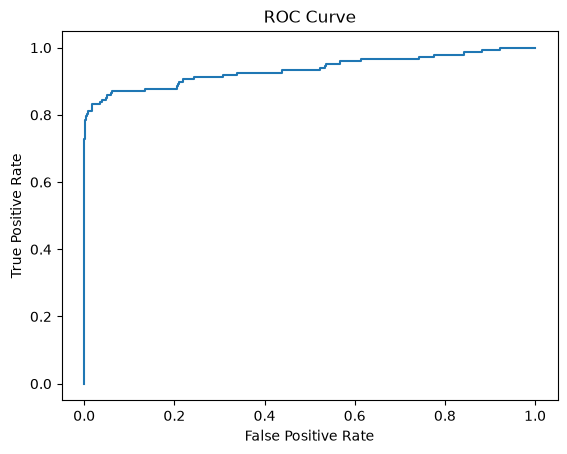

AUC:  0.9348718200585251


In [8]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

print('AUC: ', roc_auc_score(y_test, y_probs))

### Curva Precision-Recall
Mais informativa que a ROC aqui: com ~0,17% de fraudes, o que importa é a relação entre falsos positivos e fraudes não detectadas.

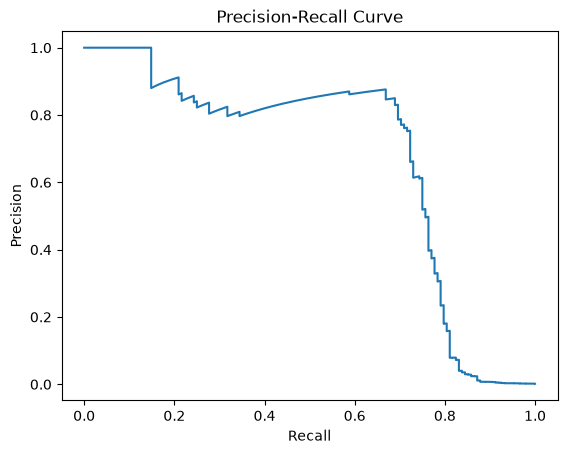

In [9]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()



### Balanceamento de classes: UnderSampling
Reduz a classe majoritária (transações normais) para igualar ao número de fraudes.

In [10]:
# UnderSampling

fraudes = df[df['Class'] == 1]
normais = df[df['Class'] == 0].sample(len(fraudes), random_state=42)

# df_under é criado mas não é usado em nenhum treino abaixo - até aqui é só exploração,
# não interfere no restante do pipeline
df_under = pd.concat([fraudes, normais])

### Balanceamento de classes: OverSampling (SMOTE)
Gera exemplos sintéticos da classe minoritária (fraude) em vez de descartar dados da classe majoritária.

In [11]:
# OverSampling

from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_res, y_res = smote.fit_resample(X, y)

### Random Forest com `class_weight='balanced'`
Alternativa ao SMOTE/undersampling: penaliza mais os erros na classe minoritária durante o treino, sem alterar o dataset.

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50, 
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



### Pipeline de pré-processamento + modelo
Encapsula scaler e classificador em um único objeto, facilitando reprodutibilidade e uso em produção.

In [13]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000))
])

pipeline.fit(X_train, y_train)

y_pred_pipeline = pipeline.predict(X_test)

### Ajustando o threshold de decisão
O ponto de corte padrão (0.5) não é obrigatório - pode ser movido para priorizar recall ou precisão conforme o custo do erro.

In [14]:
# Ajuste de threshold sobre as probabilidades da Regressão Logística original. 
# Baixar o corte de 0.5 para 0.3 tende a aumentar recall (pega mais fraudes) 
# e reduzir precisão (mais falsos positivos) - trade-off típico em fraude,
# onde deixar passar uma fraude costuma custar mais que investigar um alarme falso.
threshold = 0.3

y_pred_custom = (y_probs >= threshold).astype(int)
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.77      0.70      0.73       148

    accuracy                           1.00     85443
   macro avg       0.88      0.85      0.87     85443
weighted avg       1.00      1.00      1.00     85443



### XGBoost com `scale_pos_weight`
Gradient boosting, geralmente mais forte que Random Forest/Regressão Logística em dados tabulares; `scale_pos_weight` compensa o desbalanceamento.

In [15]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10,  # Ajuda para lidar com o desbalanceamento
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

c:\Users\vinac\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:29:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



### Importância das variáveis (XGBoost)

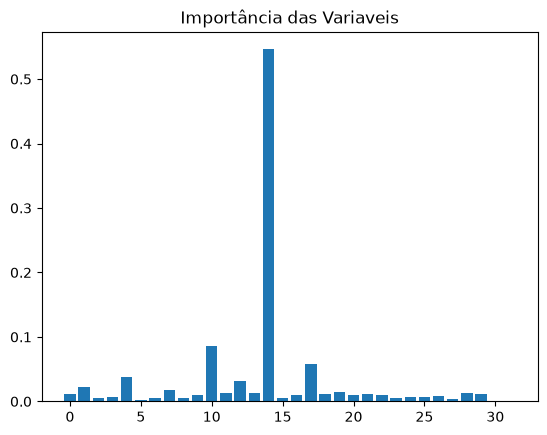

In [16]:
importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das Variaveis")
plt.show()

### Busca de hiperparâmetros (GridSearchCV)
Varre combinações de `max_depth` e `n_estimators` otimizando recall via validação cruzada.

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",  # otimizando recall
    cv=3
)

grid.fit(X_train, y_train)

# grid.best_params_ é só impresso; o modelo final (grid.best_estimator_) não é usado para
# gerar um novo classification_report - falta esse passo para saber se de fato melhorou o xgb.
print("Melhor Modelo:", grid.best_params_)

Melhor Modelo: {'max_depth': 5, 'n_estimators': 100}


### Interpretabilidade com SHAP
Mostra a contribuição média de cada variável para as previsões do XGBoost, indo além da importância bruta de features.

c:\Users\vinac\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


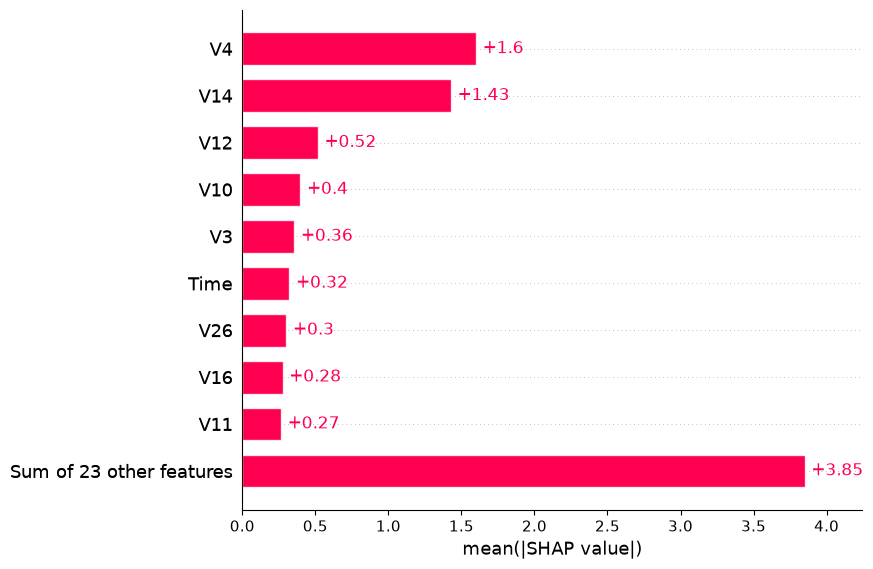

In [18]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(X_test[:100])

shap.plots.bar(shap_values)